# Pair Classifier — Match vs. Ambiguous (LightGBM, v1)

**Problem.** A variant of the same *entity resolution* task, but with a different target and a
restricted population. Instead of predicting *match vs. not-match*, here we only look at pairs
that a human considered *plausible* and ask: is this a **confident match** or an **ambiguous**
pair (one a human found genuinely hard to call)?

**Population (the key difference from the match/not-match notebook).** We keep only pairs that
are a **match** (`final_gold_label = True`) **or** flagged **ambiguous** (`ambiguous_pair = True`).
Pairs that are *neither a match nor ambiguous* (confident non-matches) are **dropped entirely** —
they are not part of this problem.

**Target.** `ambiguous_pair`:

| class | meaning |
|-------|---------|
| `0` | **confident match** — a match the annotator was sure about (`final_gold_label=True`, not ambiguous) |
| `1` | **ambiguous** — the annotator found this pair hard to call (`ambiguous_pair=True`) |

So a positive prediction means *"route this to human review"* rather than *"these are the same
person"*. The model is effectively an **ambiguity / hard-case detector** over the pool of
plausible pairs.

**v1 keeps the features deliberately simple:** for each selected field we only ask whether the
two records' values are the *same string*, *different*, or *one/both missing*. Later iterations
will add string-similarity, phonetics, date deltas, etc.

**Notebook structure**
1. Setup & configuration
2. Data ingestion (merge gold labels with cleaned records)
3. Population filter (match ∪ ambiguous) + target definition
4. Field selection
5. Feature engineering (`same` / `different` / `missing` per field)
6. Train / validation / test split
7. Model training
8. Model evaluation

> Scope note: this is a **standalone training/evaluation notebook**. It is *not* wired into
> the production pipeline (`src/pipeline.py`) yet.

## 1. Setup & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [2]:
from pathlib import Path

# Resolve empi-service/ by walking up from the notebook until we find a data/ dir.
# Works regardless of how deep under notebooks/ this file lives, or the launch cwd.
def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")

SERVICE_ROOT = _find_service_root(Path.cwd())
DATA_DIR = SERVICE_ROOT / 'data'

GOLD_LABELS_PATH = DATA_DIR / 'gold_labels' / 'final_gold_labels_v1_2026_07_05.csv'
CLEANED_PATH = DATA_DIR / 'processed' / 'MDM_Population_cleaned_v6_2026_06_25.parquet'

print('service root :', SERVICE_ROOT)
print('gold labels  :', GOLD_LABELS_PATH, '-> exists:', GOLD_LABELS_PATH.exists())
print('cleaned data :', CLEANED_PATH, '-> exists:', CLEANED_PATH.exists())

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
gold labels  : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\gold_labels\final_gold_labels_v1_2026_07_05.csv -> exists: True
cleaned data : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\processed\MDM_Population_cleaned_v6_2026_06_25.parquet -> exists: True


## 2. Data ingestion

We load two inputs and join them into one pair-level table:

- **Gold labels** — one row per annotated pair: `PATID_A`, `PATID_B`, `ambiguous_pair`, `final_gold_label`.
- **Cleaned records** — one row per `PATID` with the cleaned attributes.

For each pair we attach side-`A` and side-`B` copies of the record attributes.

> **Leading-zeros invariant:** `PATID` (and SSN/ZIP) are *digit strings, not integers*.
> The gold-label CSV is read with `dtype=str` so a `PATID` like `0012345` is not silently
> coerced to `12345`. The cleaned data is Parquet, which preserves dtypes natively.

In [3]:
# Gold labels: force string PATIDs (leading-zeros invariant); parse the two flags.
gold = pd.read_csv(
    GOLD_LABELS_PATH,
    dtype={'PATID_A': str, 'PATID_B': str},
)


def _to_bool(s: pd.Series) -> pd.Series:
    """Robustly parse a boolean-ish column (handles True/False, 1/0, 'true'/'false')."""
    if s.dtype == bool:
        return s
    return (
        s.astype(str).str.strip().str.lower().map(
            {'true': True, '1': True, '1.0': True,
             'false': False, '0': False, '0.0': False}
        )
    )


gold['final_gold_label'] = _to_bool(gold['final_gold_label'])
gold['ambiguous_pair'] = _to_bool(gold['ambiguous_pair'])

print('gold labels shape :', gold.shape)
print('\nfinal_gold_label distribution:')
print(gold['final_gold_label'].value_counts(dropna=False))
print('\nambiguous_pair distribution:')
print(gold['ambiguous_pair'].value_counts(dropna=False))

gold labels shape : (204805, 4)

final_gold_label distribution:
final_gold_label
False    142268
True      62537
Name: count, dtype: int64

ambiguous_pair distribution:
ambiguous_pair
False    176755
True      28050
Name: count, dtype: int64


In [4]:
# Fill any NaN flags so the boolean masks below are well-defined.
gold['final_gold_label'] = gold['final_gold_label'].fillna(False).astype(bool)
gold['ambiguous_pair'] = gold['ambiguous_pair'].fillna(False).astype(bool)

# Cross-tabulate the two flags to see the four cells before filtering.
print('final_gold_label x ambiguous_pair (counts):')
print(pd.crosstab(gold['final_gold_label'], gold['ambiguous_pair']))

final_gold_label x ambiguous_pair (counts):
ambiguous_pair     False  True 
final_gold_label               
False             142195     73
True               34560  27977


In [5]:
# Cleaned records: one row per PATID. Keep only the attribute columns we may
# use as features, plus PATID as the join key.
ATTRIBUTE_COLS = [
    'FirstNM_clean',
    'LastNM_clean',
    'MiddleNM_clean',
    'BirthDT_clean',
    'SSN_clean',
    'last_4_SSN',
    'Email_clean',
    'ZipCD_clean_base',
    'AddressLine1_clean',
    'SexAtBirthDSC_clean',
    'Phones_set',
]

cleaned = pd.read_parquet(CLEANED_PATH)
keep = ['PATID'] + [c for c in ATTRIBUTE_COLS if c in cleaned.columns]
cleaned = cleaned[keep].copy()
cleaned['PATID'] = cleaned['PATID'].astype(str)

# One record per PATID (defensive: keep first if duplicates exist).
cleaned = cleaned.drop_duplicates(subset='PATID', keep='first').set_index('PATID')
print('cleaned records shape:', cleaned.shape)
print('columns available    :', list(cleaned.columns))

cleaned records shape: (163364, 11)
columns available    : ['FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean', 'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base', 'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set']


In [6]:
# Attach A-side and B-side attributes to every pair via two indexed joins.
a = cleaned.add_suffix('_A').reindex(gold['PATID_A'].values).reset_index(drop=True)
b = cleaned.add_suffix('_B').reindex(gold['PATID_B'].values).reset_index(drop=True)

pairs = pd.concat([gold.reset_index(drop=True), a, b], axis=1)

# Sanity check: how many pairs reference a PATID missing from the cleaned data?
missing_a = ~gold['PATID_A'].isin(cleaned.index)
missing_b = ~gold['PATID_B'].isin(cleaned.index)
n_unmatched = (missing_a | missing_b).sum()
print(f'pairs with a PATID not found in cleaned data: {n_unmatched} / {len(pairs)}')
if n_unmatched:
    print('  -> these pairs will have all-missing attributes on the unmatched side.')
print('joined pairs shape:', pairs.shape)

pairs with a PATID not found in cleaned data: 0 / 204805
joined pairs shape: (204805, 26)


## 3. Population filter + target definition

**This is what makes this notebook different.** We restrict the population to pairs that are
*plausible* and drop the confident non-matches:

- **Keep** a pair if it is a **match** (`final_gold_label = True`) **or** **ambiguous**
  (`ambiguous_pair = True`).
- **Drop** a pair that is *neither* — i.e. `final_gold_label = False` **and**
  `ambiguous_pair = False` (a confident non-match). These are not part of this problem.

The **target** is then `ambiguous_pair`:

- `0` = **confident match** (kept because `final_gold_label=True`, and not ambiguous)
- `1` = **ambiguous** (kept because `ambiguous_pair=True`)

> Edge case: a handful of pairs may be `final_gold_label=False` **and** `ambiguous_pair=True`
> (annotator leaned "not a match" but still flagged it hard). They are ambiguous by definition,
> so they stay in and are labeled `1`. The crosstab printed above shows how many such pairs exist.

In [7]:
# Keep only plausible pairs: match OR ambiguous. Drop confident non-matches.
keep_mask = pairs['final_gold_label'] | pairs['ambiguous_pair']
n_before = len(pairs)
pairs = pairs[keep_mask].reset_index(drop=True)
n_dropped = n_before - len(pairs)

print(f'dropped {n_dropped} confident non-match pairs '
      f'(final_gold_label=False & ambiguous_pair=False)')
print(f'{len(pairs)} plausible pairs remain\n')

# Target: 1 = ambiguous, 0 = confident match.
pairs['target_ambiguous'] = pairs['ambiguous_pair'].astype(int)

print('target distribution (0=confident match, 1=ambiguous):')
print(pairs['target_ambiguous'].value_counts())
print(f"\npositive (ambiguous) rate: {pairs['target_ambiguous'].mean():.3f}")

dropped 142195 confident non-match pairs (final_gold_label=False & ambiguous_pair=False)
62610 plausible pairs remain

target distribution (0=confident match, 1=ambiguous):
target_ambiguous
0    34560
1    28050
Name: count, dtype: int64

positive (ambiguous) rate: 0.448


## 4. Field selection

Pick which record fields drive the features. **This is the main knob to change between
iterations** — add or remove entries in `SELECTED_FIELDS` and re-run from here down.

`AVAILABLE_FIELDS` maps a short feature name to its cleaned-column name.

In [8]:
# name -> cleaned column. Fields marked in SET_FIELDS are set-valued (see below).
AVAILABLE_FIELDS = {
    'first_name':  'FirstNM_clean',
    'last_name':   'LastNM_clean',
    'middle_name': 'MiddleNM_clean',
    'birth_date':  'BirthDT_clean',
    'email':       'Email_clean',
    'ssn':         'SSN_clean',        # full 9-digit SSN
    'address1':    'AddressLine1_clean',
    'phones':      'Phones_set',       # set-valued: see SET_FIELDS
    # ---- available but not used in v1 ----
    # 'ssn_last4':  'last_4_SSN',
    # 'zip':        'ZipCD_clean_base',
    # 'sex':        'SexAtBirthDSC_clean',
}

# Set-valued fields: a record can hold several values (e.g. multiple phones).
# These are compared by *overlap* rather than exact equality (see feature engineering).
SET_FIELDS = {'phones'}

# v1 field set.
SELECTED_FIELDS = [
    'first_name', 'last_name', 'middle_name', 'birth_date',
    'email', 'ssn', 'address1', 'phones',
]

assert set(SELECTED_FIELDS) <= set(AVAILABLE_FIELDS), 'unknown field in SELECTED_FIELDS'
print('using fields:', SELECTED_FIELDS)

using fields: ['first_name', 'last_name', 'middle_name', 'birth_date', 'email', 'ssn', 'address1', 'phones']


## 5. Feature engineering

For each selected field we build a single 3-level categorical feature comparing the two sides:

| value | meaning |
|-------|---------|
| `missing`   | one or both sides have no value |
| `same`      | the values match |
| `different` | both present but do not match |

**Scalar fields** (names, DOB, email, SSN, address) are normalized (stripped, case-folded) and
compared for exact equality.

**Set-valued fields** (`SET_FIELDS`, e.g. `phones`) hold several values per record. They are
compared by **overlap**: if the two records share *at least one* value the feature is `same`;
if both sides are non-empty but disjoint it is `different`; if either side is empty it is
`missing`.

The columns are stored as pandas `category` dtype, which LightGBM consumes as native categorical
features.

In [9]:
import ast

MISSING, SAME, DIFFERENT = 'missing', 'same', 'different'
COMPARE_LEVELS = [MISSING, SAME, DIFFERENT]


def _normalize(s: pd.Series) -> pd.Series:
    """Normalize a scalar field for equality: strings stripped + lowercased; other dtypes
    untouched. Empty / placeholder strings become NaN so they count as missing."""
    if s.dtype == object or pd.api.types.is_string_dtype(s):
        out = s.astype('string').str.strip().str.lower()
        return out.replace({'': pd.NA, 'nan': pd.NA, 'none': pd.NA})
    return s


def _parse_set(value) -> set:
    """Parse a set-valued cell (phones) into a set of strings. Handles the native
    array/list form Parquet round-trips as well as the legacy stringified-set form
    (e.g. \"{'7735551234', '3125559876'}\")."""
    if isinstance(value, (set, frozenset, list, tuple, np.ndarray)):
        return {str(p).strip() for p in value if str(p).strip()}
    if pd.isna(value) or not isinstance(value, str):
        return set()
    v = value.strip()
    if v in ('', 'nan', 'None', 'set()', '{}', '[]'):
        return set()
    try:
        parsed = ast.literal_eval(v)
        if isinstance(parsed, (set, list, tuple)):
            return {str(p).strip() for p in parsed if str(p).strip()}
    except (ValueError, SyntaxError, TypeError):
        pass
    cleaned = v.strip('{}[]').replace("'", '').replace('"', '')
    return {p.strip() for p in cleaned.split(',') if p.strip()}


def compare_field(df: pd.DataFrame, name: str, col: str) -> pd.Categorical:
    """Return a 3-level (missing/same/different) comparison for one field.

    Set-valued fields (name in SET_FIELDS) are 'same' when the two records share at
    least one value; scalar fields are 'same' on normalized exact equality."""
    if name in SET_FIELDS:
        a = df[f'{col}_A'].apply(_parse_set)
        b = df[f'{col}_B'].apply(_parse_set)
        missing = (a.map(len) == 0) | (b.map(len) == 0)
        overlap = pd.Series([bool(x & y) for x, y in zip(a, b)], index=df.index)
        same = overlap & ~missing
    else:
        a = _normalize(df[f'{col}_A'])
        b = _normalize(df[f'{col}_B'])
        missing = a.isna() | b.isna()
        same = (a == b) & ~missing
    out = np.where(missing, MISSING, np.where(same, SAME, DIFFERENT))
    return pd.Categorical(out, categories=COMPARE_LEVELS)


features = pd.DataFrame(index=pairs.index)
for name in SELECTED_FIELDS:
    features[f'cmp_{name}'] = compare_field(pairs, name, AVAILABLE_FIELDS[name])

FEATURE_COLS = list(features.columns)
print('feature columns:', FEATURE_COLS)
features.head()

feature columns: ['cmp_first_name', 'cmp_last_name', 'cmp_middle_name', 'cmp_birth_date', 'cmp_email', 'cmp_ssn', 'cmp_address1', 'cmp_phones']


,cmp_first_name,cmp_last_name,cmp_middle_name,cmp_birth_date,cmp_email,cmp_ssn,cmp_address1,cmp_phones
0,same,same,missing,same,missing,missing,same,same
1,same,same,missing,same,different,missing,same,same
2,different,same,missing,same,missing,missing,same,same
3,same,same,missing,same,same,same,different,same
4,same,same,missing,same,missing,missing,different,different


In [10]:
# Quick look: how does each comparison feature relate to the target (ambiguous vs match)?
for fcol in FEATURE_COLS:
    print(f'\n=== {fcol} vs target_ambiguous (row-normalized) ===')
    ct = pd.crosstab(features[fcol], pairs['target_ambiguous'], normalize='index')
    ct.columns = ['confident_match(0)', 'ambiguous(1)'][:ct.shape[1]]
    print(ct.round(3))


=== cmp_first_name vs target_ambiguous (row-normalized) ===
                confident_match(0)  ambiguous(1)
cmp_first_name                                  
same                         0.516         0.484
different                    0.888         0.112

=== cmp_last_name vs target_ambiguous (row-normalized) ===
               confident_match(0)  ambiguous(1)
cmp_last_name                                  
missing                     1.000         0.000
same                        0.580         0.420
different                   0.431         0.569

=== cmp_middle_name vs target_ambiguous (row-normalized) ===
                 confident_match(0)  ambiguous(1)
cmp_middle_name                                  
missing                       0.538         0.462
same                          0.905         0.095
different                     0.832         0.168

=== cmp_birth_date vs target_ambiguous (row-normalized) ===
                confident_match(0)  ambiguous(1)
cmp_birth_date       

## 6. Train / validation / test split

**Random stratified** split on the target (60% train / 20% validation / 20% test).
Stratifying keeps the ambiguous/confident-match ratio stable across splits.

> Note: a random *pair* split can place two pairs that share a record on opposite sides of the
> split, so the test estimate is mildly optimistic. A PATID-grouped split removes that; it's a
> natural next iteration.

In [11]:
X = features
y = pairs['target_ambiguous'].astype(int)

idx = np.arange(len(X))
# First carve off the test set (20%), then split the rest into train/val (75/25 -> 60/20).
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y.iloc[idx_trainval]
)

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{name:5s}: n={len(yy):5d}  ambiguous={yy.sum():5d}  amb_rate={yy.mean():.3f}')

train: n=37566  ambiguous=16830  amb_rate=0.448
val  : n=12522  ambiguous= 5610  amb_rate=0.448
test : n=12522  ambiguous= 5610  amb_rate=0.448


## 7. Model training

A LightGBM classifier with sensible, conservative defaults for a small tabular dataset with
few (categorical) features. `class_weight='balanced'` guards against label imbalance, and we
use **early stopping on the validation set** so `n_estimators` is an upper bound rather than a
tuned value. Hyperparameter tuning comes in a later pass.

In [12]:
params = dict(
    objective='binary',
    n_estimators=1000,       # upper bound; early stopping picks the real count
    learning_rate=0.05,
    num_leaves=15,           # small: few features, avoid overfitting
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=FEATURE_COLS,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)
print('best iteration:', model.best_iteration_)
print('best val AUC  :', round(model.best_score_['valid_0']['auc'], 4))

best iteration: 311
best val AUC  : 0.9507


## 8. Model evaluation

Evaluated on the held-out **test** set: threshold-based report + confusion matrix, then
threshold-free ROC / PR curves, feature importances, and the score distribution.

The positive class is **ambiguous** — so *recall* here is the share of genuinely ambiguous
pairs the model would route to human review, and *precision* is how many of the pairs it flags
as ambiguous really were.

In [25]:
DECISION_THRESHOLD = 0.3

proba_test = model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= DECISION_THRESHOLD).astype(int)

print('Classification report (test):\n')
print(classification_report(
    y_test, pred_test,
    target_names=['confident match (0)', 'ambiguous (1)'], digits=3,
))
print(f'ROC AUC : {roc_auc_score(y_test, proba_test):.4f}')
print(f'PR  AUC : {average_precision_score(y_test, proba_test):.4f}')

Classification report (test):

                     precision    recall  f1-score   support

confident match (0)      0.981     0.818     0.892      6912
      ambiguous (1)      0.814     0.980     0.890      5610

           accuracy                          0.891     12522
          macro avg      0.898     0.899     0.891     12522
       weighted avg      0.906     0.891     0.891     12522

ROC AUC : 0.9461
PR  AUC : 0.8976


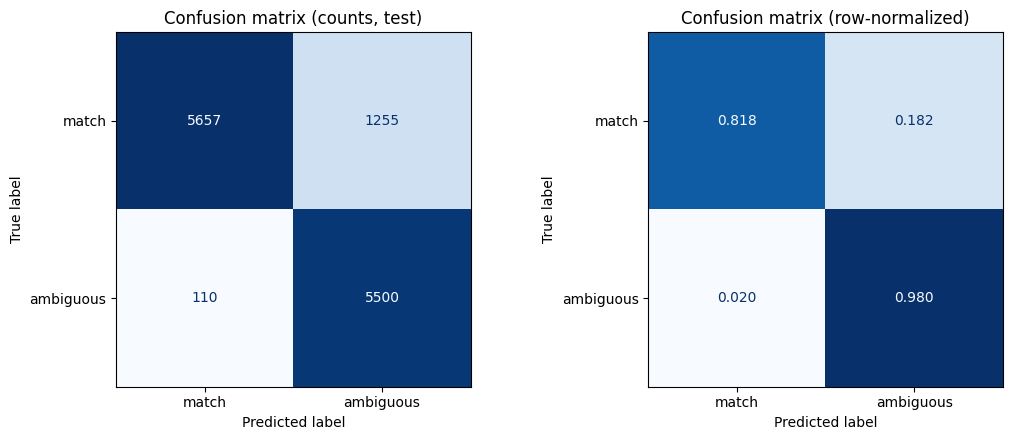

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

labels = ['match', 'ambiguous']
cm = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title('Confusion matrix (counts, test)')

cm_norm = confusion_matrix(y_test, pred_test, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(ax=ax[1], colorbar=False, cmap='Blues', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

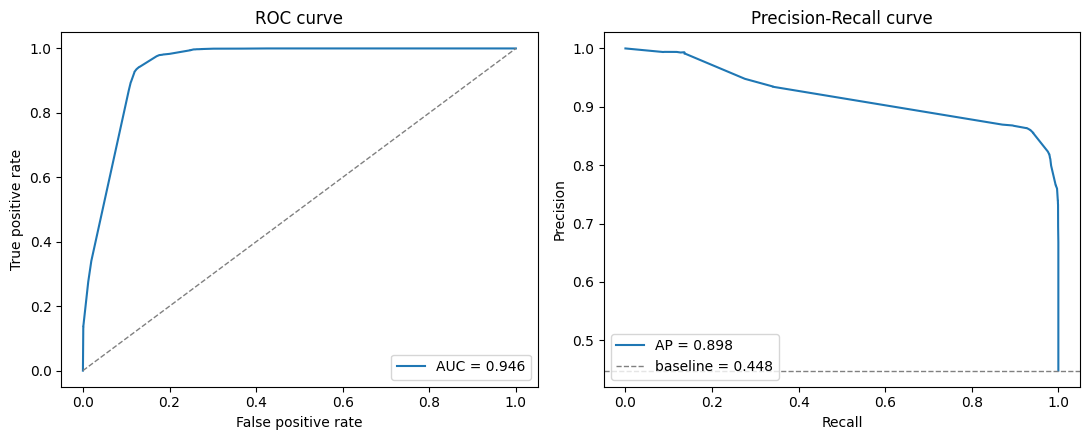

In [27]:
# ROC and Precision-Recall curves.
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, proba_test):.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve')
ax[0].legend(loc='lower right')

ax[1].plot(rec, prec, label=f'AP = {average_precision_score(y_test, proba_test):.3f}')
ax[1].axhline(y_test.mean(), ls='--', color='grey', linewidth=1, label=f'baseline = {y_test.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve')
ax[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

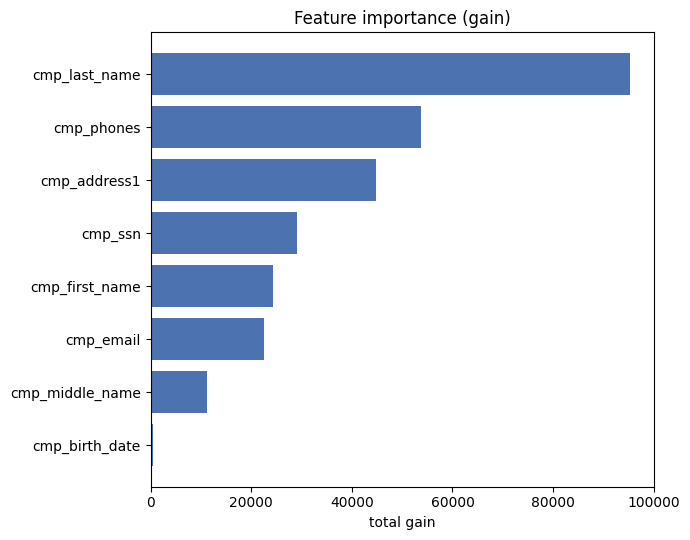

,feature,gain,split
1,cmp_last_name,95272.991403,613
7,cmp_phones,53689.751813,715
6,cmp_address1,44819.683373,712
5,cmp_ssn,29119.899129,586
0,cmp_first_name,24315.887399,516
4,cmp_email,22610.723295,637
2,cmp_middle_name,11271.207498,408
3,cmp_birth_date,437.871082,167


In [28]:
# Feature importance (gain).
imp = pd.DataFrame({
    'feature': model.feature_name_,
    'gain': model.booster_.feature_importance(importance_type='gain'),
    'split': model.booster_.feature_importance(importance_type='split'),
}).sort_values('gain', ascending=False)

fig, ax = plt.subplots(figsize=(7, 0.5 * len(imp) + 1.5))
ax.barh(imp['feature'][::-1], imp['gain'][::-1], color='#4C72B0')
ax.set(title='Feature importance (gain)', xlabel='total gain')
plt.tight_layout()
plt.show()
imp

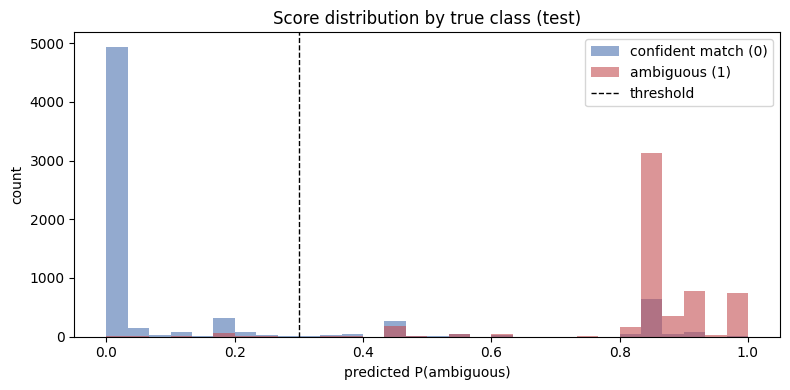

In [29]:
# Predicted-probability distribution by true class (how separable is the score?).
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 31)
ax.hist(proba_test[y_test == 0], bins=bins, alpha=0.6, label='confident match (0)', color='#4C72B0')
ax.hist(proba_test[y_test == 1], bins=bins, alpha=0.6, label='ambiguous (1)', color='#C44E52')
ax.axvline(DECISION_THRESHOLD, ls='--', color='black', linewidth=1, label='threshold')
ax.set(xlabel='predicted P(ambiguous)', ylabel='count', title='Score distribution by true class (test)')
ax.legend()
plt.tight_layout()
plt.show()

### Notes for the next iteration

- **Richer features:** string similarity (Jaro-Winkler / Levenshtein) on names, phonetic codes,
  day/month/year date deltas, SSN-last4 exact, ZIP prefix — beyond the 3-way same/diff/missing.
  Ambiguity is likely driven by *partial* agreement (a name that's close but not identical), which
  the coarse same/different/missing encoding cannot capture — this is the most promising lever here.
- **More fields:** enable additional entries in `AVAILABLE_FIELDS` / `SELECTED_FIELDS`.
- **Leakage-safe split:** switch to a PATID-grouped split for a stricter generalization estimate.
- **Threshold & tuning:** tune `DECISION_THRESHOLD` for the desired precision/recall trade-off on
  the ambiguous class (this drives the size of the human-review queue), and run hyperparameter
  search over the LightGBM params.
- **Class definition:** revisit the handful of `final_gold_label=False & ambiguous_pair=True`
  pairs — confirm they belong in the ambiguous class rather than being a separate 'confident
  non-match but flagged' case.